In [1]:
!pip install statsmodels torch torchvision matplotlib pandas scikit-learn --quiet


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from statsmodels.tsa.arima.model import ARIMA

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE


'cuda'

        Date  Temp
0 1981-01-01  20.7
1 1981-01-02  17.9
2 1981-01-03  18.8
3 1981-01-04  14.6
4 1981-01-05  15.8
Total length: 3650


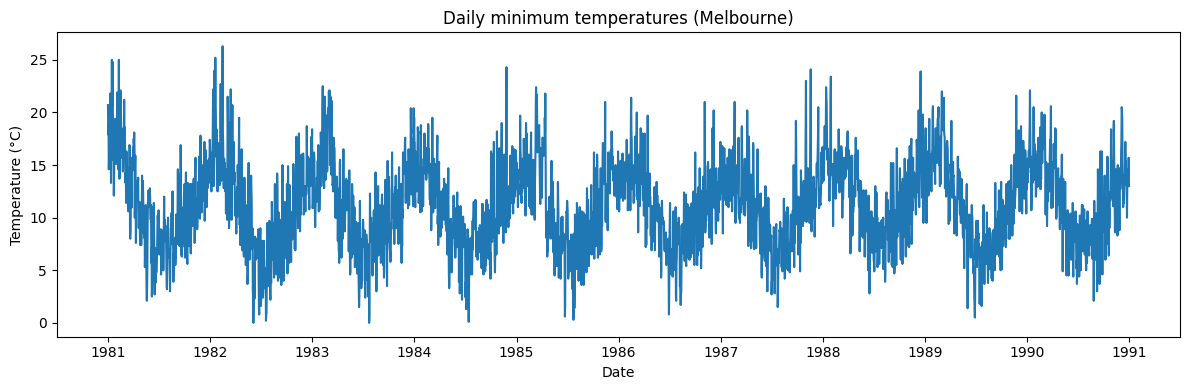

In [3]:
# Daily minimum temperatures dataset (Melbourne)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

df = pd.read_csv(url, parse_dates=["Date"])
df = df.sort_values("Date")

print(df.head())
print("Total length:", len(df))

plt.figure(figsize=(12,4))
plt.plot(df["Date"], df["Temp"])
plt.title("Daily minimum temperatures (Melbourne)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()


In [4]:
values = df["Temp"].values.astype("float32").reshape(-1, 1)

scaler = MinMaxScaler()
values_scaled = scaler.fit_transform(values).astype("float32").flatten()

N = len(values_scaled)
train_end = int(N * 0.7)
val_end = int(N * 0.85)

train = values_scaled[:train_end]
val = values_scaled[train_end:val_end]
test = values_scaled[val_end:]

print("Train length:", len(train))
print("Val length:", len(val))
print("Test length:", len(test))


Train length: 2555
Val length: 547
Test length: 548


In [5]:
def make_supervised(series, window_size):
    """
    X[i] = series[i-window_size:i]
    y[i] = series[i]
    """
    X, y = [], []
    for i in range(window_size, len(series)):
        X.append(series[i-window_size:i])
        y.append(series[i])
    return np.array(X), np.array(y)

window_size = 14  # use last 14 days to predict tomorrow

X_train, y_train = make_supervised(train, window_size)
X_val, y_val     = make_supervised(val, window_size)
X_test, y_test   = make_supervised(test, window_size)

print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape, "y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape, "y_test shape:", y_test.shape)


X_train shape: (2541, 14) y_train shape: (2541,)
X_val shape: (533, 14) y_val shape: (533,)
X_test shape: (534, 14) y_test shape: (534,)


In [6]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100.0

def evaluate_series(y_true, y_pred):
    return {
        "MSE": float(mean_squared_error(y_true, y_pred)),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "MAPE": float(mape(y_true, y_pred)),
    }


In [7]:
def naive_forecast(history):
    return history[-1]

def moving_average_forecast(history, window):
    window = min(window, len(history))
    return history[-window:].mean()

# For fairness: use only test segment for baselines
# y_test corresponds to test[window_size:]
naive_preds = []
ma_preds = []

for i in range(window_size, len(test)):
    history = test[i-window_size:i]
    naive_preds.append(naive_forecast(history))
    ma_preds.append(moving_average_forecast(history, window=window_size))

naive_preds = np.array(naive_preds)
ma_preds = np.array(ma_preds)

# inverse scale for metrics
def inverse_scale(arr_scaled):
    return scaler.inverse_transform(arr_scaled.reshape(-1, 1)).flatten()

y_test_inv = inverse_scale(y_test)
naive_inv  = inverse_scale(naive_preds)
ma_inv     = inverse_scale(ma_preds)

metrics_naive = evaluate_series(y_test_inv, naive_inv)
metrics_ma    = evaluate_series(y_test_inv, ma_inv)

print("Naive baseline metrics:", metrics_naive)
print("Moving average metrics:", metrics_ma)


Naive baseline metrics: {'MSE': 6.686816692352295, 'MAE': 2.045318365097046, 'MAPE': 22.090566635131836}
Moving average metrics: {'MSE': 6.3524298667907715, 'MAE': 1.9602060317993164, 'MAPE': 20.998685836791992}


In [8]:
# Fit ARIMA on train+val (scaled)
series_tv = np.concatenate([train, val])

order = (5, 1, 0)  # you can tune this
arima_model = ARIMA(series_tv, order=order)
arima_fit = arima_model.fit()
print(arima_fit.summary())

# Forecast full test length
arima_forecast_full = arima_fit.forecast(steps=len(test))

# Align with y_test (which skips first window_size points of test)
arima_preds = arima_forecast_full[window_size:]

arima_inv = inverse_scale(arima_preds)
metrics_arima = evaluate_series(y_test_inv, arima_inv)

print("ARIMA metrics:", metrics_arima)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3102
Model:                 ARIMA(5, 1, 0)   Log Likelihood                2881.914
Date:                Mon, 17 Nov 2025   AIC                          -5751.827
Time:                        14:29:08   BIC                          -5715.590
Sample:                             0   HQIC                         -5738.815
                               - 3102                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3319      0.016    -20.570      0.000      -0.363      -0.300
ar.L2         -0.3866      0.017    -22.114      0.000      -0.421      -0.352
ar.L3         -0.2864      0.019    -15.323      0.0

In [9]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, 1)
        out, _ = self.lstm(x)
        out = out[:, -1, :]        # last time step
        out = self.fc(out)
        return out.squeeze(-1)


def make_loader(X, y, batch_size=32, shuffle=True):
    X_t = torch.from_numpy(X).float().unsqueeze(-1)  # (N, seq, 1)
    y_t = torch.from_numpy(y).float()
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


In [10]:
batch_size = 32
hidden_size = 32
num_layers = 1
epochs = 20
lr = 1e-3

train_loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
val_loader   = make_loader(X_val, y_val, batch_size=batch_size, shuffle=False)
test_loader  = make_loader(X_test, y_test, batch_size=batch_size, shuffle=False)

model = LSTMForecaster(
    input_size=1,
    hidden_size=hidden_size,
    num_layers=num_layers,
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item() * len(xb)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch}: train MSE={train_loss:.4f}, val MSE={val_loss:.4f}")

# Forecast on test
model.eval()
lstm_preds_scaled = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        preds = model(xb)
        lstm_preds_scaled.append(preds.cpu().numpy())
lstm_preds_scaled = np.concatenate(lstm_preds_scaled, axis=0)

lstm_inv = inverse_scale(lstm_preds_scaled)
metrics_lstm = evaluate_series(y_test_inv, lstm_inv)

print("LSTM metrics:", metrics_lstm)


Epoch 1: train MSE=0.0733, val MSE=0.0169
Epoch 2: train MSE=0.0166, val MSE=0.0165
Epoch 3: train MSE=0.0127, val MSE=0.0104
Epoch 4: train MSE=0.0113, val MSE=0.0102
Epoch 5: train MSE=0.0112, val MSE=0.0104
Epoch 6: train MSE=0.0112, val MSE=0.0102
Epoch 7: train MSE=0.0116, val MSE=0.0098
Epoch 8: train MSE=0.0111, val MSE=0.0102
Epoch 9: train MSE=0.0108, val MSE=0.0097
Epoch 10: train MSE=0.0106, val MSE=0.0096
Epoch 11: train MSE=0.0104, val MSE=0.0097
Epoch 12: train MSE=0.0104, val MSE=0.0094
Epoch 13: train MSE=0.0102, val MSE=0.0092
Epoch 14: train MSE=0.0100, val MSE=0.0088
Epoch 15: train MSE=0.0098, val MSE=0.0086
Epoch 16: train MSE=0.0096, val MSE=0.0083
Epoch 17: train MSE=0.0094, val MSE=0.0085
Epoch 18: train MSE=0.0092, val MSE=0.0082
Epoch 19: train MSE=0.0092, val MSE=0.0085
Epoch 20: train MSE=0.0090, val MSE=0.0080
LSTM metrics: {'MSE': 5.038843631744385, 'MAE': 1.7558338642120361, 'MAPE': 19.740217208862305}


In [11]:
metrics = {
    "naive": metrics_naive,
    "moving_average": metrics_ma,
    "arima": metrics_arima,
    "lstm": metrics_lstm,
}

metrics


{'naive': {'MSE': 6.686816692352295,
  'MAE': 2.045318365097046,
  'MAPE': 22.090566635131836},
 'moving_average': {'MSE': 6.3524298667907715,
  'MAE': 1.9602060317993164,
  'MAPE': 20.998685836791992},
 'arima': {'MSE': 60.262441252130884,
  'MAE': 6.7768779644502555,
  'MAPE': 55.84902863054072},
 'lstm': {'MSE': 5.038843631744385,
  'MAE': 1.7558338642120361,
  'MAPE': 19.740217208862305}}

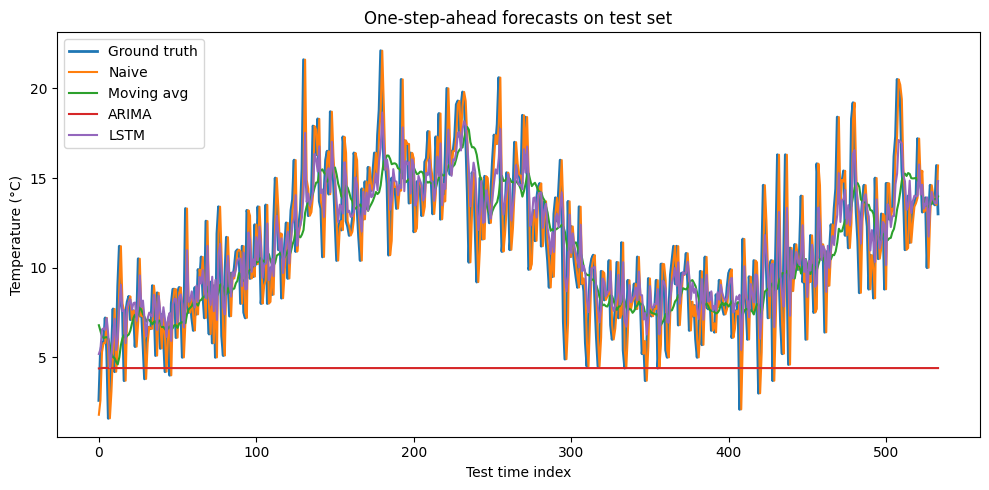

In [12]:
plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label="Ground truth", linewidth=2)
plt.plot(naive_inv,  label="Naive")
plt.plot(ma_inv,     label="Moving avg")
plt.plot(arima_inv,  label="ARIMA")
plt.plot(lstm_inv,   label="LSTM")

plt.xlabel("Test time index")
plt.ylabel("Temperature (°C)")
plt.title("One-step-ahead forecasts on test set")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
import os
os.makedirs("results", exist_ok=True)
plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label="Ground truth", linewidth=2)
plt.plot(naive_inv,  label="Naive")
plt.plot(ma_inv,     label="Moving avg")
plt.plot(arima_inv,  label="ARIMA")
plt.plot(lstm_inv,   label="LSTM")
plt.xlabel("Test time index")
plt.ylabel("Temperature (°C)")
plt.title("One-step-ahead forecasts on test set")
plt.legend()
plt.tight_layout()
plt.savefig("results/example_forecasts.png", dpi=200)
plt.close()


Using device: cuda
        Date  Temp
0 1981-01-01  20.7
1 1981-01-02  17.9
2 1981-01-03  18.8
3 1981-01-04  14.6
4 1981-01-05  15.8
Total length: 3650


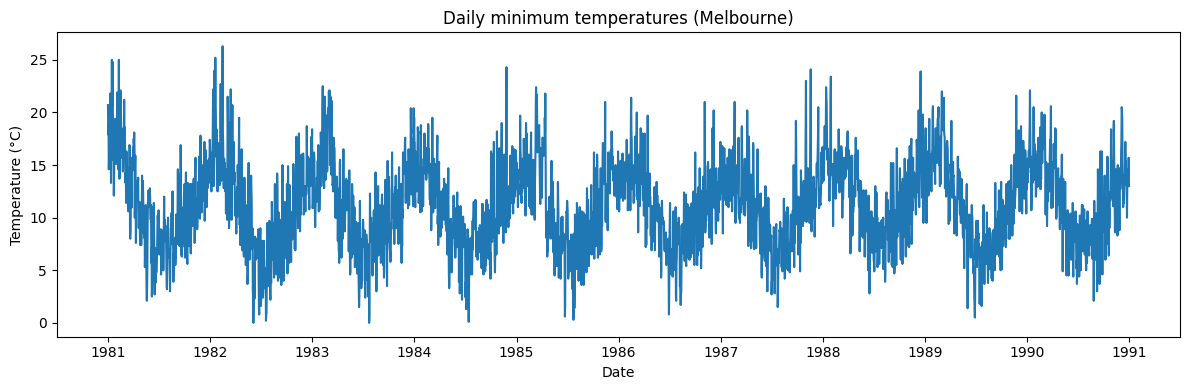

Train length: 2555
Val length: 547
Test length: 548
X_train shape: (2541, 14) y_train shape: (2541,)
X_val shape: (533, 14) y_val shape: (533,)
X_test shape: (534, 14) y_test shape: (534,)
Naive baseline metrics: {'MSE': 6.686816692352295, 'MAE': 2.045318365097046, 'MAPE': 22.090566635131836}
Moving average metrics: {'MSE': 6.3524298667907715, 'MAE': 1.9602060317993164, 'MAPE': 20.998685836791992}


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA metrics (rolling 1-step): {'MSE': 5.3396074468026224, 'MAE': 1.7980577283894028, 'MAPE': 19.488110941216142}
Epoch 1: train MSE=0.0495, val MSE=0.0175
Epoch 2: train MSE=0.0161, val MSE=0.0124
Epoch 3: train MSE=0.0118, val MSE=0.0123
Epoch 4: train MSE=0.0114, val MSE=0.0101
Epoch 5: train MSE=0.0111, val MSE=0.0104
Epoch 6: train MSE=0.0113, val MSE=0.0107
Epoch 7: train MSE=0.0111, val MSE=0.0103
Epoch 8: train MSE=0.0108, val MSE=0.0098
Epoch 9: train MSE=0.0108, val MSE=0.0100
Epoch 10: train MSE=0.0106, val MSE=0.0095
Epoch 11: train MSE=0.0105, val MSE=0.0094
Epoch 12: train MSE=0.0105, val MSE=0.0093
Epoch 13: train MSE=0.0106, val MSE=0.0092
Epoch 14: train MSE=0.0102, val MSE=0.0092
Epoch 15: train MSE=0.0104, val MSE=0.0091
Epoch 16: train MSE=0.0101, val MSE=0.0098
Epoch 17: train MSE=0.0102, val MSE=0.0089
Epoch 18: train MSE=0.0100, val MSE=0.0088
Epoch 19: train MSE=0.0099, val MSE=0.0087
Epoch 20: train MSE=0.0099, val MSE=0.0086
LSTM metrics: {'MSE': 5.4116110801

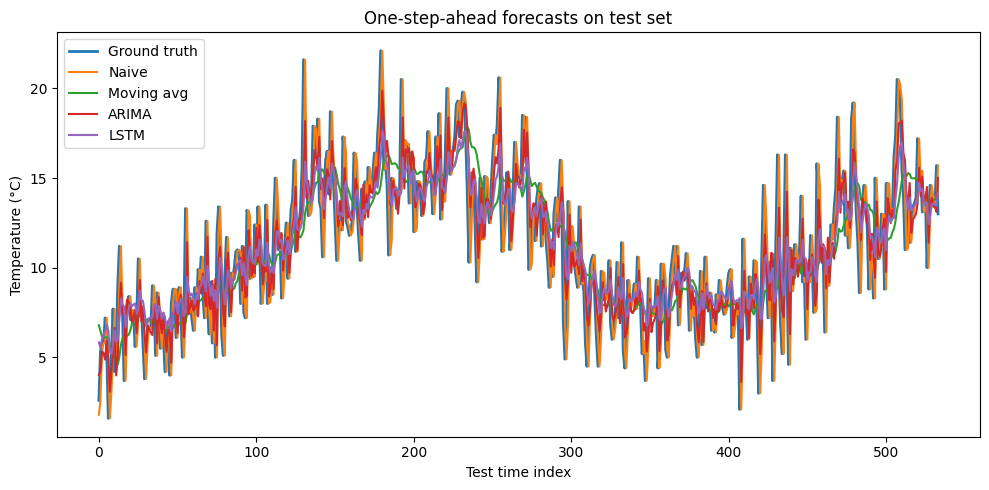

In [14]:
# ============================================================
# 0. Install dependencies (Colab)
# ============================================================
!pip install statsmodels torch torchvision matplotlib pandas scikit-learn --quiet

# ============================================================
# 1. Imports & device
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from statsmodels.tsa.arima.model import ARIMA

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ============================================================
# 2. Load dataset & quick plot
# ============================================================
# Daily minimum temperatures dataset (Melbourne)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

df = pd.read_csv(url, parse_dates=["Date"])
df = df.sort_values("Date")

print(df.head())
print("Total length:", len(df))

plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df["Temp"])
plt.title("Daily minimum temperatures (Melbourne)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

# ============================================================
# 3. Train / Val / Test split + scaling
#    (fit scaler on TRAIN ONLY for good hygiene)
# ============================================================
values = df["Temp"].values.astype("float32")
N = len(values)

train_end = int(N * 0.7)
val_end = int(N * 0.85)

train_raw = values[:train_end].reshape(-1, 1)
val_raw   = values[train_end:val_end].reshape(-1, 1)
test_raw  = values[val_end:].reshape(-1, 1)

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw).astype("float32").flatten()
val_scaled   = scaler.transform(val_raw).astype("float32").flatten()
test_scaled  = scaler.transform(test_raw).astype("float32").flatten()

print("Train length:", len(train_scaled))
print("Val length:", len(val_scaled))
print("Test length:", len(test_scaled))

# ============================================================
# 4. Make supervised data (for LSTM)
# ============================================================
def make_supervised(series, window_size):
    """
    X[i] = series[i-window_size:i]
    y[i] = series[i]
    """
    X, y = [], []
    for i in range(window_size, len(series)):
        X.append(series[i-window_size:i])
        y.append(series[i])
    return np.array(X), np.array(y)

window_size = 14  # use last 14 days to predict tomorrow

X_train, y_train = make_supervised(train_scaled, window_size)
X_val, y_val     = make_supervised(val_scaled, window_size)
X_test, y_test   = make_supervised(test_scaled, window_size)

print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape, "y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape, "y_test shape:", y_test.shape)

# ============================================================
# 5. Metrics helpers
# ============================================================
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100.0

def evaluate_series(y_true, y_pred):
    return {
        "MSE": float(mean_squared_error(y_true, y_pred)),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "MAPE": float(mape(y_true, y_pred)),
    }

def inverse_scale(arr_scaled):
    arr_scaled = np.asarray(arr_scaled).reshape(-1, 1)
    return scaler.inverse_transform(arr_scaled).flatten()

# ground truth in original units (for all models)
y_test_inv = inverse_scale(y_test)

# ============================================================
# 6. Baselines: Naive & Moving Average (on scaled test)
# ============================================================
def naive_forecast(history):
    return history[-1]

def moving_average_forecast(history, window):
    window = min(window, len(history))
    return history[-window:].mean()

naive_preds = []
ma_preds = []

# y_test corresponds to test_scaled[window_size:]
for i in range(window_size, len(test_scaled)):
    history = test_scaled[i-window_size:i]
    naive_preds.append(naive_forecast(history))
    ma_preds.append(moving_average_forecast(history, window=window_size))

naive_preds = np.array(naive_preds)
ma_preds = np.array(ma_preds)

naive_inv = inverse_scale(naive_preds)
ma_inv    = inverse_scale(ma_preds)

metrics_naive = evaluate_series(y_test_inv, naive_inv)
metrics_ma    = evaluate_series(y_test_inv, ma_inv)

print("Naive baseline metrics:", metrics_naive)
print("Moving average metrics:", metrics_ma)

# ============================================================
# 7. ARIMA (rolling 1-step-ahead forecasts)
# ============================================================
# Work on scaled data
series_tv = np.concatenate([train_scaled, val_scaled])

order = (5, 1, 0)

history = list(series_tv)
arima_forecasts = []

# Rolling 1-step ahead: fit on history, forecast 1 step, then update with real test value
for t in range(len(test_scaled)):
    model = ARIMA(history, order=order)
    model_fit = model.fit()
    yhat = model_fit.forecast(steps=1)[0]
    arima_forecasts.append(yhat)
    history.append(test_scaled[t])

arima_forecasts = np.array(arima_forecasts)

# Align with y_test (which is test_scaled[window_size:])
arima_preds = arima_forecasts[window_size:]

arima_inv = inverse_scale(arima_preds)
metrics_arima = evaluate_series(y_test_inv, arima_inv)

print("ARIMA metrics (rolling 1-step):", metrics_arima)

# ============================================================
# 8. LSTM model (PyTorch)
# ============================================================
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, 1)
        out, _ = self.lstm(x)
        out = out[:, -1, :]        # last time step
        out = self.fc(out)
        return out.squeeze(-1)

def make_loader(X, y, batch_size=32, shuffle=True):
    X_t = torch.from_numpy(X).float().unsqueeze(-1)  # (N, seq, 1)
    y_t = torch.from_numpy(y).float()
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

batch_size = 32
hidden_size = 32
num_layers = 1
epochs = 20
lr = 1e-3

train_loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
val_loader   = make_loader(X_val, y_val, batch_size=batch_size, shuffle=False)
test_loader  = make_loader(X_test, y_test, batch_size=batch_size, shuffle=False)

model = LSTMForecaster(
    input_size=1,
    hidden_size=hidden_size,
    num_layers=num_layers,
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item() * len(xb)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch}: train MSE={train_loss:.4f}, val MSE={val_loss:.4f}")

# Forecast on test
model.eval()
lstm_preds_scaled = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        preds = model(xb)
        lstm_preds_scaled.append(preds.cpu().numpy())
lstm_preds_scaled = np.concatenate(lstm_preds_scaled, axis=0)

lstm_inv = inverse_scale(lstm_preds_scaled)
metrics_lstm = evaluate_series(y_test_inv, lstm_inv)

print("LSTM metrics:", metrics_lstm)

# ============================================================
# 9. Collect metrics & plot
# ============================================================
metrics = {
    "naive": metrics_naive,
    "moving_average": metrics_ma,
    "arima": metrics_arima,
    "lstm": metrics_lstm,
}

import json
print("All metrics:")
print(json.dumps(metrics, indent=2))

plt.figure(figsize=(10, 5))
plt.plot(y_test_inv, label="Ground truth", linewidth=2)
plt.plot(naive_inv,  label="Naive")
plt.plot(ma_inv,     label="Moving avg")
plt.plot(arima_inv,  label="ARIMA")
plt.plot(lstm_inv,   label="LSTM")

plt.xlabel("Test time index")
plt.ylabel("Temperature (°C)")
plt.title("One-step-ahead forecasts on test set")
plt.legend()
plt.tight_layout()
plt.show()

# Save plot for GitHub README
import os
os.makedirs("results", exist_ok=True)
plt.figure(figsize=(10, 5))
plt.plot(y_test_inv, label="Ground truth", linewidth=2)
plt.plot(naive_inv,  label="Naive")
plt.plot(ma_inv,     label="Moving avg")
plt.plot(arima_inv,  label="ARIMA")
plt.plot(lstm_inv,   label="LSTM")
plt.xlabel("Test time index")
plt.ylabel("Temperature (°C)")
plt.title("One-step-ahead forecasts on test set")
plt.legend()
plt.tight_layout()
plt.savefig("results/example_forecasts.png", dpi=200)
plt.close()
